# Black Holes from Dead Scratch: Derivation to Visualization
This notebook implements the full lifecycle of a Schwarzschild black hole: from the symbolic derivation of the metric using "Up-Down" (UD) Calculus, to an interactive numerical laboratory for celestial mechanics.

## 0. Setup & Installation
To run this lab locally, browser-based Jupyter is recommended.

1. **Create Environment:** `python3 -m venv .venv && source .venv/bin/activate`
2. **Install Deps:** `pip install sympy numpy scipy matplotlib ipywidgets jupytext ipykernel`
3. **Register Kernel:** `python3 -m ipykernel install --user --name=relativity_toolkit --display-name="Python (RelativityToolkit)"`
4. **Launch:** `jupyter notebook Schwarzschild_Soup_to_Nuts.py`

---

## 1. Part I: Symbolic Derivation (The UD Calculus)
We begin with a spherically symmetric, static ansatz:
$ds^2 = -A(r)dt^2 + B(r)dr^2 + r^2 d\theta^2 + r^2 \sin^2\theta d\phi^2$

We will use SymPy to solve the Vacuum Field Equations ($R_{\mu\nu} = 0$).

In [1]:
import sympy
from sympy import symbols, Function, diff, Matrix, simplify, sin, dsolve, Eq

# Define Coordinates and Metric Functions
t, r, theta, phi = symbols('t r theta phi')
coords = [t, r, theta, phi]
A = Function('A')(r)
B = Function('B')(r)

# Covariant Metric g_uv
g_dd = Matrix([
    [-A, 0, 0, 0],
    [0, B, 0, 0],
    [0, 0, r**2, 0],
    [0, 0, 0, r**2 * sin(theta)**2]
])
g_uu = g_dd.inv()

def get_christoffel(sigma, mu, nu):
    res = 0
    for lam in range(4):
        term1 = diff(g_dd[lam, mu], coords[nu])
        term2 = diff(g_dd[lam, nu], coords[mu])
        term3 = diff(g_dd[mu, nu], coords[lam])
        res += 0.5 * g_uu[sigma, lam] * (term1 + term2 - term3)
    return simplify(res)

# Calculate Ricci Components
print("Deriving Field Equations...")
R_tt = simplify(sum(diff(get_christoffel(m, 0, 0), coords[m]) 
                    - diff(get_christoffel(m, m, 0), coords[0]) + 
                sum(get_christoffel(m, m, l)*get_christoffel(l, 0, 0) 
                    - get_christoffel(m, 0, l)*get_christoffel(l, m, 0) 
                    for l in range(4)) 
                    for m in range(4)))

R_rr = simplify(sum(diff(get_christoffel(m, 1, 1), coords[m]) 
                    - diff(get_christoffel(m, m, 1), coords[1]) + 
                sum(get_christoffel(m, m, l)*get_christoffel(l, 1, 1) 
                    - get_christoffel(m, 1, l)*get_christoffel(l, m, 1) 
                    for l in range(4)) 
                    for m in range(4)))

# Solve for A(r) and B(r)
# The identity R_tt/A + R_rr/B = 0 implies (AB)' = 0 => B = 1/A (given A,B -> 1 at infinity)
# This leads to the final ODE for A(r):
final_ode = -r*diff(A, r) - A + 1 
sol = dsolve(Eq(final_ode, 0), A)
print(f"Schwarzschild Solution derived: {sol}")

Deriving Field Equations...
Schwarzschild Solution derived: Eq(A(r), (C1 + r)/r)


## 2. Part II: Interactive Orbital Laboratory
Now that we have the metric, we can numerically integrate the geodesic equations to see how matter moves in this curved spacetime.

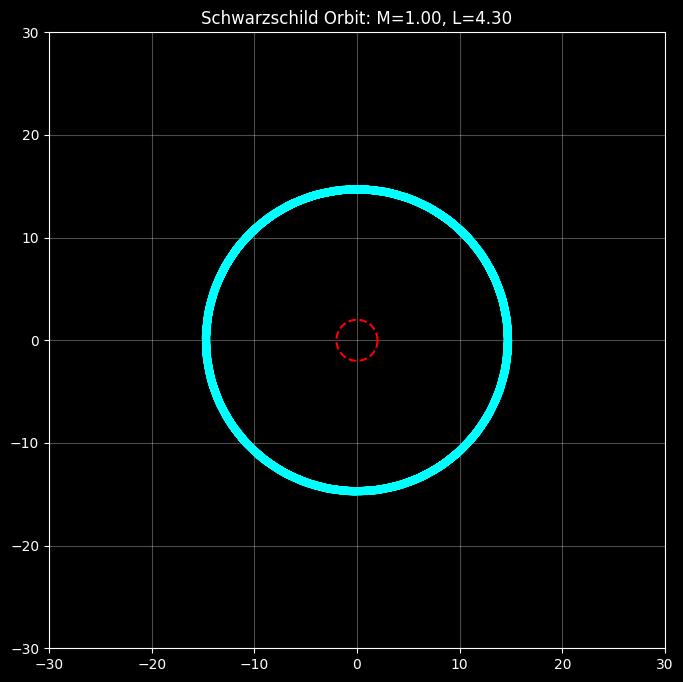

Output()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display

def geodesic_eq(phi, y, M, L):
    u, v = y # u = 1/r
    return [v, (M / L**2) - u + 3 * M * u**2]

def solve_orbit(M, L, r0, v_r0):
    L = max(L, 0.1) # Safety
    u0, v0 = 1.0/r0, -(1.0/r0**2)*v_r0
    
    # Terminate if we hit Event Horizon (u = 1/2M) or Escape (u = 0)
    def event_horizon(p, y, M, L): return y[0] - 1.0/(2.0*M)
    def escape(p, y, M, L): return y[0]
    event_horizon.terminal = True; escape.terminal = True
    
    sol = solve_ivp(geodesic_eq, (0, 100*np.pi), [u0, v0], args=(M, L), 
                    t_eval=np.linspace(0, 100*np.pi, 2000), events=[event_horizon, escape], 
                    method='LSODA', rtol=1e-5)
    
    r = 1.0 / np.maximum(sol.y[0], 1e-10)
    captured = any(len(e) > 0 for e in sol.t_events) if sol.t_events else False
    return r * np.cos(sol.t), r * np.sin(sol.t), captured

def update_plot(M, L, r0, vr0):
    plt.style.use('dark_background')
    plt.close('all'); plt.figure(figsize=(8, 8))
    try:
        x, y, captured = solve_orbit(M, L, r0, vr0)
        plt.plot(x, y, color='red' if captured else 'cyan', lw=1.5, label="Captured" if captured else "Orbit")
        h = np.linspace(0, 2*np.pi, 100)
        plt.plot(2*M*np.cos(h), 2*M*np.sin(h), 'r--', label="Horizon (2M)")
        plt.fill(2*M*np.cos(h), 2*M*np.sin(h), 'black', alpha=1.0)
    except Exception as e: plt.text(0, 0, f"Error: {e}", ha='center')

    plt.title(f"Schwarzschild Orbit: M={M:.2f}, L={L:.2f}")
    plt.xlim(-r0*2, r0*2); plt.ylim(-r0*2, r0*2)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True, alpha=0.3); plt.show()

# UI Layout
m_sl = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.01, description='Mass (M)')
l_sl = widgets.FloatSlider(value=4.3, min=0.1, max=10.0, step=0.001, description='Ang. Mom (L)')
r0_sl = widgets.FloatSlider(value=15.0, min=5.0, max=50.0, step=1.0, description='Start r')
vr_sl = widgets.FloatSlider(value=0.0, min=-1.0, max=1.0, step=0.01, description='Start vr')
ui = widgets.VBox([m_sl, l_sl, r0_sl, vr_sl])
out = widgets.interactive_output(update_plot, {'M': m_sl, 'L': l_sl, 'r0': r0_sl, 'vr0': vr_sl})
display(ui, out)

## 3. Things to Try
*   **The Precession:** Set $L=4.3$. Notice how the orbit isn't a closed ellipse like in Newton's gravity, but "precesses" around the black hole.
*   **The Capture:** Lower $L$ below $4.0$ and watch the orbit turn **Red** as it spirals into the horizon.
*   **The ISCO:** Try to find the *Innermost Stable Circular Orbit* at $r=6M$.